In [ ]:
#TODO
# SAM, MedSAM(fine-tuned decoder), SAMMed2D(fine-tuned all) results over 51 datasets

#### How can we fine tune SAM efficitively with the least data?  

1. Will different selection query give us diferent results?    
constraint:  
 dataset size:51 (40 train; 11 test)  
 epochs: 1000 for add one sample 
 fixed random seed  
 model: SAM  
 checkpoint: b  
 fine-tuning structure: mask decoder  

* baseline: random selection from 40 dataset
* entropy with dropout 
* entropy with dropout + artifacts
* encoder of SAM + clustering  



- Plot: Accuracy on the 11 test set as a function of number of selected samples (training)
- ID of selected samples for each iteration

In [1]:
import datasets.path as path
# import nibabel as nib
from glob import glob
import os
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import monai
# from utils.SurfaceDice import compute_dice_coefficient
from tqdm import tqdm
import json
from segment_anything import SamPredictor, sam_model_registry
from segment_anything.utils.transforms import ResizeLongestSide
import matplotlib.pyplot as plt
import wandb
from utils import NpzDataset, get_bbox_from_mask
from metrics import compute_dice_coefficient


In [2]:
# training and sampling dataset path prefix
prefix = './datasets/RAINE_organ_51'
task = 'MRI_Pancreas'
training_pool_path = os.path.join(prefix, task, 'train')
# label id
# left kidney: 1,
# right kidney: 2,
# pancreas: 3,
# background: 0,
label_id = 3

#SAM MODEL TYPE 
sam_model_type = 'vit_b'
# SAM checkpoint
checkpoint = './checkpoints/SAM/sam_vit_b_01ec64.pth'
# device 
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


# sample strategy
strategy = 'random'
# active learning fine tunning checkpoint
base_model = 'SAM'
save_path_ckp = os.path.join('./checkpoints/', base_model + '_' + task + '_' + strategy)
os.makedirs(save_path_ckp, exist_ok=True)
# sampling dataset path
sampling_datapath = os.path.join(prefix, task, base_model+'_sampling')
os.makedirs(sampling_datapath, exist_ok=True)

In [16]:
training_pool = glob(os.path.join(training_pool_path, '*.npz'))
sample_pool = []
num_epochs = 1
batch_size = 16 # make sure batch size is smaller than sample slices
losses = []
best_loss = 1e10
sam_model = sam_model_registry[sam_model_type](checkpoint=checkpoint).to(device)
sam_model.train()
# Set up the optimizer, hyperparameter tuning will improve performance here
optimizer = torch.optim.Adam(sam_model.mask_decoder.parameters(), lr=1e-5, weight_decay=0)
seg_loss = monai.losses.DiceCELoss(sigmoid=True, squared_pred=True, reduction='mean')

save_path_ckp_epoch = os.path.join(save_path_ckp, f'epoch{num_epochs}')
os.makedirs(save_path_ckp_epoch, exist_ok=True)

# wandb
wandb.init(
    # Set the project where this run will be logged
    project="SAM-Activelearning", 
    group="random",
    name=f'{base_model}_{sam_model_type}_{task}_{strategy}_epoch{num_epochs}',
    config = {
        "task": task,
        'label_id': label_id,
        'base_model': base_model,
        "model": sam_model_type,
        "strategy": strategy,
        "num_epochs": num_epochs
    }
)


In [17]:

for i in range(len(training_pool)):
    np.random.seed(2023)
    next_sample = np.random.choice(training_pool)
    sample_pool.append(next_sample)
    training_pool.remove(next_sample)

    # next_sample = np.random.choice(training_pool)
    # sample_pool.append(next_sample)
    # training_pool.remove(next_sample)
    num_samples = len(sample_pool)
    if num_samples > 2 and num_samples <= 5:
        batch_size = 32
    elif num_samples > 5:
        batch_size = 64
    
    # print('Number of samples: ', num_samples, '\tBatch size: ', batch_size)
    sample_dataset = NpzDataset(sample_pool)
    sample_dataloader = DataLoader(sample_dataset, batch_size=batch_size, shuffle=True)
    for epoch in range(num_epochs):
        epoch_loss = 0
        for step, (image_embedding, gt2D, boxes) in enumerate(tqdm(sample_dataloader)):
            # img_embed: (B, 256, 64, 64), gt2D: (B, 1, 256, 256), bboxes: (B, 4)
            # print(f"{image_embedding.shape=}, {gt2D.shape=}, {boxes.shape=}")
            with torch.no_grad():
                box_np = boxes.numpy() # [0, 0, 256, 256]
                sam_trans = ResizeLongestSide(sam_model.image_encoder.img_size)
                box = sam_trans.apply_boxes(box_np, (gt2D.shape[-2], gt2D.shape[-1]))
                box_torch = torch.as_tensor(box, dtype=torch.float, device=device)
                if len(box_torch.shape) == 2:
                    box_torch = box_torch[:, None, :] # (B, 1, 4)
                # get prompt embeddings 
                sparse_embeddings, dense_embeddings = sam_model.prompt_encoder(
                    points=None,
                    boxes=box_torch,
                    masks=None,
                )
            # predicted masks
            # print(f"{image_embedding.shape=}, {sparse_embeddings.shape=}, {dense_embeddings.shape=}")
            mask_predictions, _ = sam_model.mask_decoder(
                image_embeddings=image_embedding.to(device), # (B, 256, 64, 64)
                image_pe=sam_model.prompt_encoder.get_dense_pe(), # (1, 256, 64, 64)
                sparse_prompt_embeddings=sparse_embeddings, # (B, 2, 256)
                dense_prompt_embeddings=dense_embeddings, # (B, 256, 64, 64)
                multimask_output=False,
            )

            loss = seg_loss(mask_predictions, gt2D.to(device))
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        epoch_loss /= step
        losses.append(epoch_loss)
        print(f'EPOCH: {epoch}, Loss: {epoch_loss}')
        wandb.log({f"Train/loss of {num_samples} num sample": epoch_loss})
        # save the latest model checkpoint
        torch.save(sam_model.state_dict(), os.path.join(save_path_ckp_epoch, f'sam_{sam_model_type}_{num_samples:02d}_latest.pth'))
        # save the best model
        if epoch_loss < best_loss:
            best_loss = epoch_loss
            torch.save(sam_model.state_dict(), os.path.join(save_path_ckp_epoch, f'sam_{sam_model_type}_{num_samples:02d}_best.pth'))

    # plot loss
    # plt.plot(losses)
    # plt.title('Dice + Cross Entropy Loss')
    # plt.xlabel('Epoch')
    # plt.ylabel('Loss')
    # # plt.show() # comment this line if you are running on a server
    # plt.savefig(os.path.join(save_path_ckp, f'sam_{sam_model_type}_{num_samples:02d}_train_loss.png'))
    # plt.close()

with open(os.path.join(sampling_datapath, f'{strategy}_pool.json'), 'w') as f:
    json.dump(sample_pool, f, indent=4)
    
wandb.finish()

100%|██████████| 3/3 [00:01<00:00,  1.62it/s]


EPOCH: 0, Loss: 1.493725210428238


100%|██████████| 4/4 [00:00<00:00,  5.45it/s]


EPOCH: 0, Loss: 1.3185901840527852


100%|██████████| 4/4 [00:01<00:00,  3.39it/s]


...

EPOCH: 0, Loss: 0.30651461764385823


100%|██████████| 21/21 [00:14<00:00,  1.46it/s]


EPOCH: 0, Loss: 0.3049212947487831


100%|██████████| 22/22 [00:15<00:00,  1.44it/s]


EPOCH: 0, Loss: 0.2985035975774129


In [3]:
def infer(imgs, embeddings, ckp_path, model_type, device):
    # infer on fine-tuned sam model
    bboxes = []
    # bbox = get_bbox_from_mask(imgs)
    bbox = np.array([0 ,0, imgs.shape[2], imgs.shape[1]])
    bboxes.append(bbox)
    
    # predict the segmentation mask using the fine-tuned model
    sam_model = sam_model_registry[model_type](checkpoint=ckp_path).to(device)

    sam_trans = ResizeLongestSide(sam_model.image_encoder.img_size)
    H, W = imgs.shape[2], imgs.shape[1] # (B, H, W, C)
    with torch.no_grad():
        # convert box to 1024x1024 grid
        bbox = sam_trans.apply_boxes(bbox, (H, W))
        box_torch = torch.as_tensor(bbox, dtype=torch.float, device=device)
        if len(box_torch.shape) == 2:
            box_torch = box_torch[:, None, :] # (B, 1, 4)
        
        sparse_embeddings, dense_embeddings = sam_model.prompt_encoder(
            points=None,
            boxes=box_torch,
            masks=None,
        )
        medsam_seg_prob, _ = sam_model.mask_decoder(
            image_embeddings=embeddings.to(device), # (B, 256, 64, 64)
            image_pe=sam_model.prompt_encoder.get_dense_pe(), # (1, 256, 64, 64)
            sparse_prompt_embeddings=sparse_embeddings, # (B, 2, 256)
            dense_prompt_embeddings=dense_embeddings, # (B, 256, 64, 64)
            multimask_output=False,
            )
        medsam_seg_prob = torch.sigmoid(medsam_seg_prob)
        # convert soft mask to hard mask
        medsam_seg_prob = medsam_seg_prob.cpu().numpy().squeeze()
        medsam_seg_prob = np.stack(medsam_seg_prob, axis=0)
        medsam_seg = (medsam_seg_prob > 0.5).astype(np.uint8)
    return medsam_seg, bboxes

In [11]:
def log_image_table(images, preds, gts, id, dice, table):
    """Log a wandb.Table with (img, pred, gts, scores)
    Args:
        images: images (B, H, W, 3)
        preds: predicted masks (B, H, W)
        gts: ground truth masks (B, H, W)
    """
    index = len(images) // 2 # log the middle slice
    table.add_data(wandb.Image(images[index][:, :, 0]), wandb.Image(preds[index, :, :,]), wandb.Image(gts[index, :, :,]), id, dice)
    wandb.log({"Val/predictions_table":table}, commit=True)

    

In [2]:
!export WANDB_BASE_URL=http://172.17.0.1:8080
# !export WANDB_API_KEY=4aaa2e71cdec13a78a42c6ceac38dd0c7235a131

wandb.login(key='4aaa2e71cdec13a78a42c6ceac38dd0c7235a131')

2023-11-20 23:55:28,793 - Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.


wandb: Currently logged in as: ye_xcheng. Use `wandb login --relogin` to force relogin
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: /clusterdata/uqxye5/.netrc


True

In [10]:
num_epochs = 50
ckp_paths = sorted(glob(os.path.join(save_path_ckp, f'epochs{num_epochs}', '*latest.pth')))
testing_pool_path = os.path.join(prefix, task, 'test')
testing_pool = glob(os.path.join(testing_pool_path, '*.npz'))
dice_test = []


# wandb
wandb.init(
    # Set the project where this run will be logged
    project="SAM-Activelearning", 
    group="random",
    name=f'{base_model}_{sam_model_type}_{task}_{strategy}_epoch{num_epochs}',
    config = {
        "task": task,
        'label_id': label_id,
        'base_model': base_model,
        "model": sam_model_type,
        "strategy": strategy,
        "num_epochs": num_epochs
    }
)
table = wandb.Table(columns=["image", "pred", "gt", 'id', 'dice'])

# eval on test set for each checkpoint
for p in tqdm(ckp_paths):
    avg_dice = []
    for t in tqdm(testing_pool):
        id = os.path.basename(t).split('.')[0]
        imgs = np.load(t)['imgs']

        dataset = NpzDataset([t])
        batch_size = len(dataset)
        dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False) # make sure batch size is larger than sample slices
        for embeddings, gts, _ in dataloader:
            preds, _ = infer(imgs, embeddings, p, sam_model_type, device)
        gts = gts[:, 0, :, :].numpy() # convert tensor to numpy (B, H, W)
        dice = compute_dice_coefficient(gts, preds)
        avg_dice.append(dice)
        if '40' in p:
            preds_int = preds * 1 # convert boolean to int
            log_image_table(imgs, preds_int, gts, id, dice, table)
    dice_test.append(np.mean(avg_dice))
    wandb.log({"Val/Dice": np.mean(avg_dice)}, commit=True)
wandb.finish()
    

 98%|█████████▊| 39/40 [11:19<00:17, 17.48s/it]wandb: WARNING Step only supports monotonically increasing values, use define_metric to set a custom x axis. For details see: https://wandb.me/define-metric
wandb: WARNING (User provided step: 0 is less than current step: 39. Dropping entry: {'predictions_table': {'_type': 'table-file', 'sha256': '9baac4d6f9c0b4e0e0d94dc12199d6e4fb5dbe1f286150a0e3e656a4a378a0cb', 'size': 122, 'artifact_path': 'wandb-client-artifact://emejzerxvdp4yvcz32mh9p00d6v9iu8vosui5q4t8tv3463a9n1lu2004sfd5vvr61vjw89a3jeqisoxlwausczh9tlhtnxbovnbaiup4xmynjzzc4tv4l3z4rn7yrp9/predictions_table.table.json', '_latest_artifact_path': 'wandb-client-artifact://b5rmqd419sfi7nvc31ogsk42dl5hsopxoc3btbd0714cxav9ijmaja4zpslxu99sil4sx8u4z479rz9vmasphbs23siji0fl00oojtsvwjr9ltey3aaxgpjlapyk9zh3:latest/predictions_table.table.json', 'path': 'media/table/predictions_table_39_9baac4d6f9c0b4e0e0d9.table.json', 'ncols': 5, 'nrows': 1}, '_timestamp': 1700483785.796418}).
wandb: WARNING (Use

Val/Dice,▁▁▃▃▁▃▃▃▃▃▄▄▅▆▆▇▇▇▇▇███▇██▇▇▇▇▇▇▇▇▇▇▇▇▇▇
Val/Dice,0.4869


In [12]:
len(ckp_paths)

40

In [14]:
p = './checkpoints/SAM_MRI_Pancreas_random/epochs50/sam_vit_b_40_latest.pth'
avg_dice = []
wandb.init(
    project="AL", 
    group='random'
    # id='volcanic-fire-2', 
    # resume=True
    )

table = wandb.Table(columns=["image", "pred", "target", 'id', 'dice'])
avg_dice = []
for t in tqdm(testing_pool):
    id = os.path.basename(t).split('.')[0]
    imgs, gts_load = np.load(t)['imgs'], np.load(t)['gts']
    # print(imgs.shape)

    dataset = NpzDataset([t])
    batch_size = len(dataset)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False) # make sure batch size is larger than sample slices
    for embeddings, gts, _ in dataloader:
        preds, _ = infer(imgs, embeddings, p, sam_model_type, device)
    gts = gts[:, 0, :, :].numpy() # convert tensor to numpy (B, H, W)
    # print(f"{imgs.shape=}, {preds.shape=}, {gts.shape=}, {gts_load.shape=}")
    # break
# break
    dice = compute_dice_coefficient(gts, preds)
    avg_dice.append(dice)
    if '40' in p:
        preds_int = preds * 1 # convert boolean to int
        log_image_table(imgs, preds_int, gts, id, dice, table)
dice_test.append(np.mean(avg_dice))
wandb.log({"Val/Dice": np.mean(avg_dice)}, commit=True)
wandb.finish()

wandb: WARNING Source type is set to 'repo' but some required information is missing from the environment. A job will not be created from this run. See https://docs.wandb.ai/guides/launch/create-job


100%|██████████| 11/11 [00:18<00:00,  1.64s/it]
wandb: WARNING Source type is set to 'repo' but some required information is missing from the environment. A job will not be created from this run. See https://docs.wandb.ai/guides/launch/create-job


Val/Dice,▁
Val/Dice,0.4869


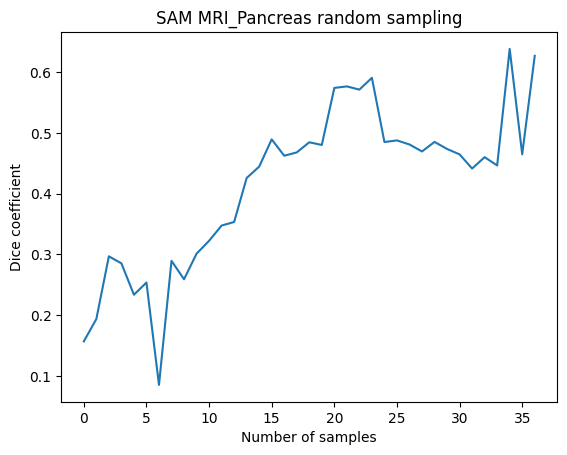

In [36]:
plt.plot(dice_test)
plt.xlabel('Number of samples')
plt.ylabel('Dice coefficient')
plt.title(f'{base_model} {task} {strategy} sampling')
plt.show()
plt.savefig(f'{base_model}_{task}_{strategy}_sampling.png')
plt.close()

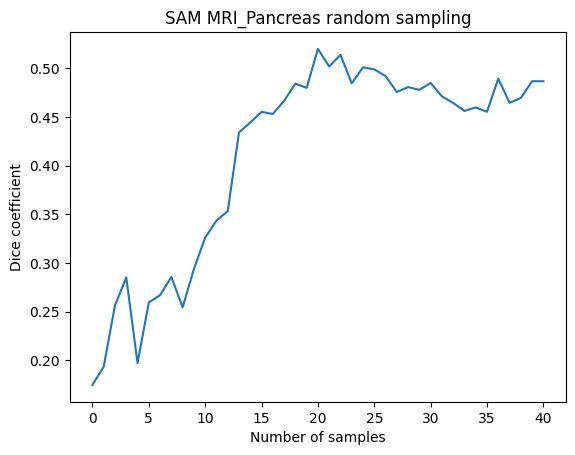

In [84]:
plt.plot(dice_test)
plt.xlabel('Number of samples')
plt.ylabel('Dice coefficient')
plt.title(f'{base_model} {task} {strategy} sampling')
plt.show()
# plt.savefig(f'{base_model}_{task}_{strategy}_sampling.png')
plt.close()